In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 180

X = pd.DataFrame({
    "PIVC": np.random.normal(0.60, 0.12, n),
    "TPJ": np.random.normal(0.55, 0.11, n),
    "Hippocampus": np.random.normal(0.63, 0.10, n),
    "Parietal": np.random.normal(0.58, 0.09, n),
    "Insula": np.random.normal(0.50, 0.10, n),
    "Cerebellum": np.random.normal(0.46, 0.11, n)
})

y = (
    35
    + X["Hippocampus"] * 22
    + X["PIVC"] * 18
    + X["Parietal"] * 14
    + np.random.normal(0, 4, n)
)

X.head()

,PIVC,TPJ,Hippocampus,Parietal,Insula,Cerebellum
0,0.659606,0.618823,0.681935,0.655212,0.530780,0.500554
1,0.583408,0.455713,0.783274,0.478326,0.328983,0.416733
2,0.677723,0.432202,0.619124,0.627682,0.365181,0.463162
3,0.782764,0.603072,0.670171,0.709741,0.574326,0.600630
4,0.571902,0.525419,0.699014,0.357552,0.517087,0.481021


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0)
}

rows = []

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rows.append([
        name,
        mean_absolute_error(y_test, pred),
        r2_score(y_test, pred)
    ])

results = pd.DataFrame(
    rows,
    columns=["model", "mae", "r2"]
)

results

,model,mae,r2
0,LinearRegression,2.865671,0.439851
1,Ridge,2.859409,0.440670


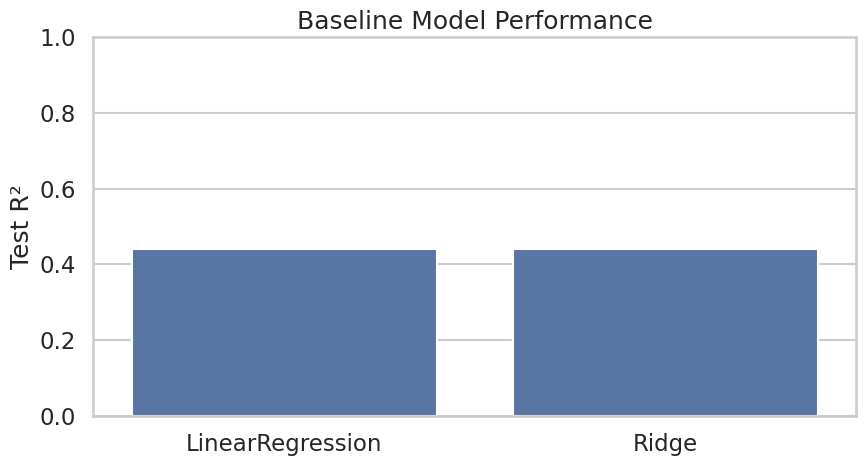

In [5]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=results,
    x="model",
    y="r2"
)

plt.ylim(0, 1)
plt.xlabel("")
plt.ylabel("Test R²")
plt.title("Baseline Model Performance")
plt.tight_layout()
plt.savefig("figures/02_model_performance.png", dpi=300)
plt.show()

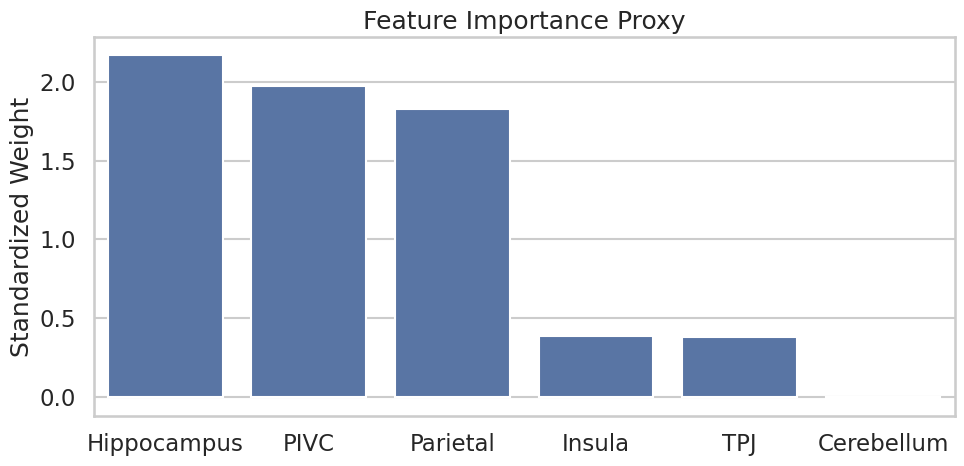

In [6]:
coef_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

coef_model.fit(X_train, y_train)

coefs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coef_model.named_steps["model"].coef_
}).sort_values("coefficient", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=coefs,
    x="feature",
    y="coefficient"
)

plt.xlabel("")
plt.ylabel("Standardized Weight")
plt.title("Feature Importance Proxy")
plt.tight_layout()
plt.savefig("figures/02_feature_weights.png", dpi=300)
plt.show()

In [7]:
results.to_csv("outputs/02_model_results.csv", index=False)
coefs.to_csv("outputs/02_feature_weights.csv", index=False)

results

,model,mae,r2
0,LinearRegression,2.865671,0.439851
1,Ridge,2.859409,0.440670
